<a href="https://colab.research.google.com/github/Western-Windows/SociaLift/blob/engagement/engagement_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 0. Install dependencies (Colab / local with internet)
%pip install -q transformers datasets accelerate sentencepiece scikit-learn torch tqdm emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 15.9 MB/s eta 0:00:00


In [2]:
# 1. Imports and configuration

import json
import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSeq2SeqLM,
    get_linear_schedule_with_warmup
)

tqdm.pandas()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [23]:
import json
import numpy as np
import pandas as pd
from tqdm import tqdm

# -------------------------------------------------------------
# 1) Load Brand Data & Build Follower Map
# -------------------------------------------------------------
with open('Facebook_Brand_Data1.json', 'r', encoding='utf-8') as f:
    brand_metadata = json.load(f)

def parse_followers(f_str):
    """Convert '~1.9M', '43K', '450' etc. to an integer."""
    if not isinstance(f_str, str):
        return np.nan
    f_str = f_str.replace('~', '').replace(',', '').strip().upper()
    mult = 1
    if 'K' in f_str:   mult = 1_000;           f_str = f_str.replace('K', '')
    elif 'M' in f_str: mult = 1_000_000;        f_str = f_str.replace('M', '')
    elif 'B' in f_str: mult = 1_000_000_000;    f_str = f_str.replace('B', '')
    try:
        return int(float(f_str) * mult)
    except ValueError:
        return np.nan

# Index both Brand Name and Username (lowercased) for maximum coverage
followers_map = {}
for brand in brand_metadata:
    val = parse_followers(brand.get('Followers', ''))
    for key in [brand.get('Brand Name', ''), brand.get('Username', '')]:
        k = str(key).lower().strip()
        if k:
            followers_map[k] = val

# -------------------------------------------------------------
# 2) Alias Map
#    Maps every post page_name variant (lowercased) that doesn't
#    directly match followers_map to the correct key that does.
#
#    Covers:
#    - Numeric-ID pages where scraper returned username as brand name
#    - Arabic subtitle appended to brand name  (Brand - Arabic)
#    - Long descriptions embedded in post page names
#    - Scraper-truncated or differently formatted brand names
# -------------------------------------------------------------
aliases = {
    # Numeric-ID pages
    '2man jeans wear'                                             : '2manjeans2man',
    '400 four hundred_egypt'                                      : '400.egypt',

    # Arabic subtitle variants
    '8west - ٨ غرب'                                               : '8west',
    'cizaro - سيزارو'                                             : 'cizaro',
    'gounela - جونلة'                                             : 'gounela',
    'lis décence - لى ديسونس'                                     : 'lis décence',
    'mlmar - casual wear'                                         : 'mlmar',
    'motion- موشن'                                                : 'motion',
    'sutra - سُترة'                                                 : 'sutra',
    'أبو الفداء - abo el-fedaa'                                   : 'أبو الفداء',

    # Long description in post page name
    'brands club - online brands clothes store from usa in egypt' : 'brandsclubegyptt',
    'creative design - التصميم الإبداعي'                          : 'creative design',
    'fashion retail group - frg'                                  : 'fashion retail group',

    # Display name ≠ scraped brand name
    'canvas wear'                                                 : 'canvas.wear.eg',
    'chertex jeans'                                               : 'chertexfactory',
    'custom clothes egy'                                          : 'custom0clothes0egy',
    'designia mall'                                               : 'malldesignia',
    'je-x'                                                        : 'jeoxstores',
    'mw fashion consultancy'                                      : 'mwfashionconsultancy',
    'shots wear'                                                  : 'shotsweareg',
    'the anime house'                                             : 'theanimeHouse'.lower(),
    'the scoop politics'                                          : 'the scoop',
    'vestiti-eg'                                                  : 'vestiti',

    # Scraper truncated brand name to single letter 'T' for both T-shirt pages
    't-shirt company'                                             : 'tshirtcompanyy',
    't-shirty'                                                    : 'tshirtprinteg',
}

# Sanity-check: all alias targets must exist in followers_map
missing_targets = {k: v for k, v in aliases.items() if v not in followers_map}
if missing_targets:
    print(f"[WARNING] {len(missing_targets)} alias target(s) not found in followers_map:")
    for k, v in missing_targets.items():
        print(f"  {k!r} -> {v!r}")

# -------------------------------------------------------------
# 3) Load Posts Data & Flatten
# -------------------------------------------------------------
with open('posts_dataset.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

flattened_rows = []
unresolved_pages = set()

for file_key, doc in tqdm(raw_data.items()):
    posts = doc.get('data', [])
    for post in posts:
        row = {}
        owing_profile = post.get('owing_profile', {})

        row['page_name']       = owing_profile.get('name') or owing_profile.get('short_name')
        row['post_text']       = post.get('context')
        row['date_of_publish'] = post.get('published_date')

        # Resolve followers: direct match → alias fallback → NaN
        search_key   = str(row['page_name']).lower().strip()
        resolved_key = aliases.get(search_key, search_key)
        followers_val = followers_map.get(resolved_key, np.nan)
        row['page_followers'] = followers_val

        if pd.isna(followers_val):
            unresolved_pages.add(row['page_name'])

        # Sub-reactions mapped from Arabic labels
        sub_reactions      = post.get('sub_reactions', {}) or {}
        row['like_count']  = sub_reactions.get('أعجبني', 0)
        row['love_count']  = sub_reactions.get('أحببته', 0)
        row['haha_count']  = sub_reactions.get('هاهاها', 0)
        row['wow_count']   = sub_reactions.get('واااو',  0)
        row['sad_count']   = sub_reactions.get('أحزنني', 0)
        row['angry_count'] = sub_reactions.get('أغضبني', 0)
        row['care_count']  = sub_reactions.get('أدعمه',  0)

        row['total_reactions'] = post.get('reaction_count.count', 0)
        row['comments_count']  = post.get('comment_rendering_instance.comments.total_count', 0)
        row['share_count']     = post.get('share_count.count', 0)

        flattened_rows.append(row)

posts_df = pd.DataFrame(flattened_rows)

print(f"\nTotal posts      : {len(posts_df)}")
print(f"Followers matched: {posts_df['page_followers'].notna().sum()}")
print(f"Followers missing: {posts_df['page_followers'].isna().sum()}")
if unresolved_pages:
    print(f"Unresolved pages ({len(unresolved_pages)}) — not present in brand data:")
    for p in sorted(unresolved_pages):
        print(f"  {p!r}")

# -------------------------------------------------------------
# 4) Calculate Weighted Engagement Score
# -------------------------------------------------------------
reaction_weights = {
    'like_count' : 1.0,
    'love_count' : 2.0,
    'haha_count' : 1.5,
    'wow_count'  : 1.5,
    'sad_count'  : 0.5,
    'angry_count': 0.5,
    'care_count' : 1.5,
    'share_count': 3.0,
}

# Ensure all numeric columns are properly typed
numeric_cols = list(reaction_weights.keys()) + ['page_followers', 'total_reactions',
                                                  'comments_count', 'share_count']
for col in numeric_cols:
    if col in posts_df.columns:
        posts_df[col] = pd.to_numeric(posts_df[col], errors='coerce')

posts_df['engagement_weighted'] = sum(
    w * posts_df[col].fillna(0) for col, w in reaction_weights.items()
)

# Engagement rate: weighted engagement normalised by follower count
followers_series = posts_df['page_followers'].replace(0, pd.NA)
posts_df['engagement_rate'] = (
    posts_df['engagement_weighted'] / followers_series
).fillna(0)

# -------------------------------------------------------------
# 5) Drop rows with no follower data then label engagement
# -------------------------------------------------------------
before = len(posts_df)
posts_df = posts_df[posts_df['page_followers'].notna() & (posts_df['page_followers'] > 0)].copy()

#ADDED MISSING DROPPING NULLS IN POSTS
# Assuming your text column is named 'post_text' (or 'context')
posts_df = posts_df.dropna(subset=['post_text'])
# Reset the index after dropping rows so your loops/batches don't break later
posts_df = posts_df.reset_index(drop=True)

print(f"\nDropped {before - len(posts_df)} rows with zero/missing followers. {len(posts_df)} rows remaining.")

# posts_df['engagement_label'] = pd.qcut(
#     posts_df['engagement_rate'], q=3, labels=['low', 'avg', 'high']
# )

#TRIAL 1 : -> SIMPLIFY FIX
# # Split into Top 33% (high engagement) and Bottom 67% (not high)
posts_df['engagement_label'] = pd.qcut(
    posts_df['engagement_rate'], q=[0, 0.67, 1.0], labels=['not_high', 'high']
)

# Update your number of labels for the model later on
NUM_LABELS = 2
print(f"\nEngagement label distribution:")
print(posts_df['engagement_label'].value_counts().to_string())

# -------------------------------------------------------------
# 6) Save Output
# -------------------------------------------------------------
posts_df.to_csv('final_dataset_with_followers.csv', index=False)
print("\nSaved → final_dataset_with_followers.csv")
print(posts_df[['page_name', 'page_followers', 'engagement_weighted',
                 'engagement_rate', 'engagement_label']].head(10).to_string())

100%|██████████| 161/161 [00:00<00:00, 6674.80it/s]



Total posts      : 4715
Followers matched: 4668
Followers missing: 47
Unresolved pages (12) — not present in brand data:
  'COMFO WEAR '
  'GLAM Fashion & Styling Agency'
  'Hassan Aboali II'
  'Limited Edition'
  'Maha Hassan'
  'Proud American Patriot'
  'Reem elmazoon'
  'Style casual wear'
  "Sue's Fashion brand"
  'Trendy moda'
  'بكار بلوجر الغلابه'
  'يوستينا صلاح - Youstina salah'

Dropped 164 rows with zero/missing followers. 4551 rows remaining.

Engagement label distribution:
engagement_label
not_high    3049
high        1502

Saved → final_dataset_with_followers.csv
  page_name  page_followers  engagement_weighted  engagement_rate engagement_label
0   Damagon           180.0                  5.0         0.027778             high
1   Trifex             70.0                  0.0         0.000000         not_high
2   Trifex             70.0                  0.0         0.000000         not_high
3   Trifex             70.0                  0.0         0.000000         not_high

/tmp/ipykernel_397/1051285674.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=posts_df, x='engagement_label', order=['low', 'avg', 'high'], palette='viridis')
/tmp/ipykernel_397/1051285674.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_pages.index, x=top_pages.values, palette='Blues_r')
/tmp/ipykernel_397/1051285674.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_eng_pages.index, x=top_eng_pages.values, palette='Oranges_r')
/tmp/ipykernel_397/1051285674.py:56: FutureWarning: 'M' is deprecated and will be re

Plots generated successfully.
153 unique pages.
4551 total posts.
  page_name                                          post_text  \
0   Damagon  مرحبًا بكم في [Damagon]!\n\nنقدم لكم تجربة فري...   
1   Trifex   Women’s Extreme Wide-Leg Jeans \nBold, relaxed...   
2   Trifex   Mafeesh Fayda Tee \nHeritage × Streetwear.\nOv...   
3   Trifex   Clean, minimal, and made for everyday comfort....   
4   shxo.eg  Comfort meets attitude — SHXO sweats.\n\n#shxo...   

      date_of_publish  page_followers  like_count  love_count  haha_count  \
0 2024-09-18 19:33:50           180.0           3           1           0   
1 2025-11-25 00:10:37            70.0           0           0           0   
2 2025-11-24 23:46:28            70.0           0           0           0   
3 2025-11-23 23:36:18            70.0           0           0           0   
4 2026-02-09 16:29:12           165.0           6           2           0   

   wow_count  sad_count  angry_count  care_count  total_reactions  \
0    

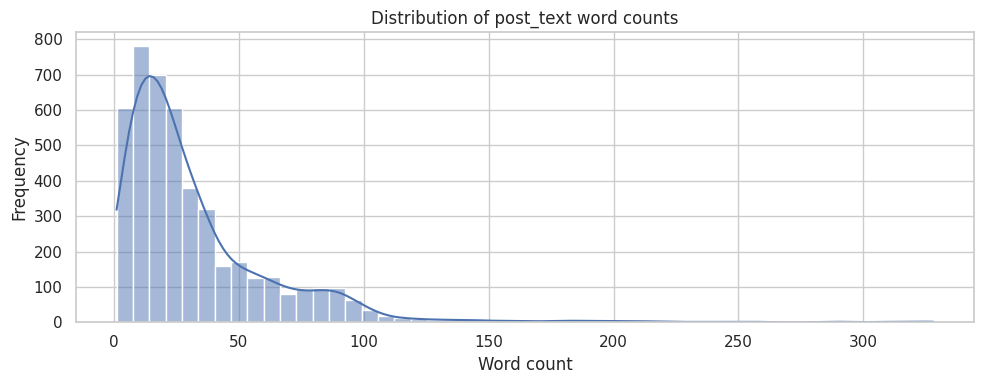

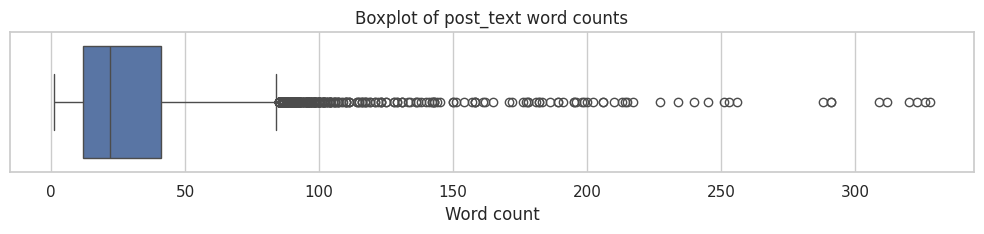

In [24]:
#gemini eda

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure date is datetime
posts_df['date_of_publish'] = pd.to_datetime(posts_df['date_of_publish'], errors='coerce')

# Set aesthetic style
sns.set_theme(style="whitegrid")

# 1. Distribution of Engagement Label
plt.figure(figsize=(8, 5))
sns.countplot(data=posts_df, x='engagement_label', order=['low', 'avg', 'high'], palette='viridis')
plt.title('Distribution of Engagement Labels')
plt.xlabel('Engagement Label')
plt.ylabel('Count')
plt.savefig('engagement_label_dist.png', bbox_inches='tight')
plt.close()

# 2. Top 10 Pages by Number of Posts
plt.figure(figsize=(10, 6))
top_pages = posts_df['page_name'].value_counts().nlargest(10)
sns.barplot(y=top_pages.index, x=top_pages.values, palette='Blues_r')
plt.title('Top 10 Pages by Number of Posts')
plt.xlabel('Number of Posts')
plt.ylabel('Page Name')
plt.savefig('top_pages_posts.png', bbox_inches='tight')
plt.close()

# 3. Average Engagement Rate by Top 10 Pages
plt.figure(figsize=(10, 6))
top_eng_pages = posts_df.groupby('page_name')['engagement_rate'].mean().nlargest(10)
sns.barplot(y=top_eng_pages.index, x=top_eng_pages.values, palette='Oranges_r')
plt.title('Top 10 Pages by Average Engagement Rate')
plt.xlabel('Average Engagement Rate')
plt.ylabel('Page Name')
plt.savefig('top_eng_pages.png', bbox_inches='tight')
plt.close()

# 4. Correlation Matrix of Metrics
plt.figure(figsize=(10, 8))
corr_cols = ['page_followers', 'like_count', 'love_count', 'haha_count', 'wow_count',
             'sad_count', 'angry_count', 'care_count', 'total_reactions',
             'comments_count', 'share_count', 'engagement_weighted', 'engagement_rate']
corr = posts_df[corr_cols].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Engagement Metrics')
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.close()

# 5. Time Series of Posts over Time
plt.figure(figsize=(12, 5))
posts_df.set_index('date_of_publish').resample('M').size().plot(color='teal', linewidth=2)
plt.title('Number of Posts Over Time (Monthly)')
plt.xlabel('Date of Publish')
plt.ylabel('Post Count')
plt.grid(True)
plt.savefig('posts_over_time.png', bbox_inches='tight')
plt.close()

# Summary statistics for text response
summary_stats = posts_df.describe().to_dict()
missing_values = posts_df.isnull().sum().to_dict()

print("Plots generated successfully.")
print(posts_df['page_name'].nunique(), "unique pages.")
print(posts_df.shape[0], "total posts.")


# Make plots look a bit nicer
sns.set(style="whitegrid")

# 2. Ensure NLTK resources are available
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
    nltk.download('punkt')
    nltk.download('wordnet')

# Quick look at the data
print(posts_df.head())

# 4. Basic text EDA on post_text
posts_df['post_text'] = posts_df['post_text'].astype(str)

# Length features
posts_df['text_length_chars'] = posts_df['post_text'].str.len()
posts_df['text_length_words'] = posts_df['post_text'].str.split().apply(len)

# Summary statistics of lengths
print(posts_df[['text_length_chars', 'text_length_words']].describe())

# Distribution of word counts
plt.figure(figsize=(10, 4))
sns.histplot(posts_df['text_length_words'], bins=50, kde=True)
plt.title('Distribution of post_text word counts')
plt.xlabel('Word count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Boxplot of word counts
plt.figure(figsize=(10, 2.5))
sns.boxplot(x=posts_df['text_length_words'])
plt.title('Boxplot of post_text word counts')
plt.xlabel('Word count')
plt.tight_layout()
plt.show()

In [25]:
# julius EDA with Preprocessing
# 1. Imports and setup
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import emoji
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


# 5. Preprocessing functions
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

#TRIAL 2: EMOJI TRANSLATION
# 1. Translate Emojis to text so the model understands them
def emoji_text(text):
    if not isinstance(text, str):
        return ""
    # Convert emojis to descriptive text (e.g., 🔥 -> :fire:)
    return emoji.demojize(text)

def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove URLs (fixed double backslash)
    text = re.sub(r"http\S+", " ", text)

    # Explicitly remove punctuation using string.punctuation (fastest method)
    # This translates all punctuation characters to None (removes them)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove any remaining non-alphanumeric characters (keep spaces)
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Normalize whitespace (fixed double backslash)
    text = re.sub(r"\s+", " ", text).strip()

    return text

def preprocess_text(text):
    # emojis = emoji_text(text)
    cleaned = clean_text(text)
    tokens = cleaned.split()
    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    # Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

# 6. Apply preprocessing with progress bar
tqdm.pandas()
posts_df['post_text_clean'] = posts_df['post_text'].progress_apply(preprocess_text)

# Inspect original vs cleaned
print(posts_df[['post_text', 'post_text_clean']].head())

# 7. Save processed dataset
output_path = 'final_dataset_with_followers_processed.csv'
posts_df.to_csv(output_path, index=False)
print(output_path)

100%|██████████| 4551/4551 [00:00<00:00, 9504.17it/s] 


                                           post_text  \
0  مرحبًا بكم في [Damagon]!\n\nنقدم لكم تجربة فري...   
1  Women’s Extreme Wide-Leg Jeans \nBold, relaxed...   
2  Mafeesh Fayda Tee \nHeritage × Streetwear.\nOv...   
3  Clean, minimal, and made for everyday comfort....   
4  Comfort meets attitude — SHXO sweats.\n\n#shxo...   

                                     post_text_clean  
0                                            damagon  
1  woman extreme wideleg jean bold relaxed easy s...  
2  mafeesh fayda tee heritage streetwear oversize...  
3  clean minimal made everyday comfort heavyweigh...  
4  comfort meet attitude shxo sweat shxo localbra...  
final_dataset_with_followers_processed.csv


In [26]:
# 4. Optional translation (only run if you *definitely* need it)

translate = False  # Set to True if you want to translate

if translate:
    translation_model_name = "Helsinki-NLP/opus-mt-mul-en"
    trans_tokenizer = AutoTokenizer.from_pretrained(translation_model_name)
    trans_model = AutoModelForSeq2SeqLM.from_pretrained(translation_model_name).to(device)

    def translate_batch(texts, max_length=128, batch_size=16):
        out = []
        for i in tqdm(range(0, len(texts), batch_size), desc="Translating"):
            batch = texts[i:i+batch_size]
            enc = trans_tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_length
            ).to(device)
            with torch.no_grad():
                gen = trans_model.generate(**enc, max_length=max_length)
            decoded = trans_tokenizer.batch_decode(gen, skip_special_tokens=True)
            out.extend(decoded)
        return out

    # Using post_text directly if translation is skipped, or creating the translated column
    posts_df["post_text_en"] = translate_batch(posts_df["post_text_clean"].astype(str).tolist())
else:
    # If no translation, we use the original text for the following steps
    posts_df["post_text_en"] = posts_df["post_text_clean"].astype(str)

In [27]:
# 5. Train/validation split and label encoding

label_encoder = LabelEncoder()
posts_df["label_id"] = label_encoder.fit_transform(posts_df["engagement_label"].astype(str))
num_labels = len(label_encoder.classes_)
print("Labels:", list(label_encoder.classes_), "num_labels:", num_labels)

train_df, val_df = train_test_split(
    posts_df,
    test_size=0.2,
    random_state=42,
    stratify=posts_df["label_id"]
)

print("Train size:", len(train_df), "Val size:", len(val_df))

Labels: ['high', 'not_high'] num_labels: 2
Train size: 3640 Val size: 911


TF-IDF + LR accuracy: 0.7650933040614709
TF-IDF + LR macro F1: 0.7388076098606645
              precision    recall  f1-score   support

        high       0.64      0.68      0.66       301
    not_high       0.84      0.81      0.82       610

    accuracy                           0.77       911
   macro avg       0.74      0.74      0.74       911
weighted avg       0.77      0.77      0.77       911



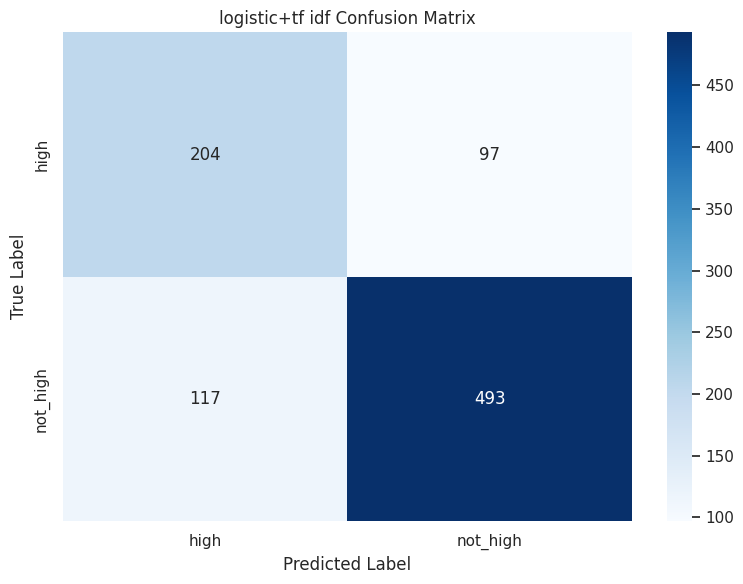

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# 6. TF-IDF + Logistic Regression baseline

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3
)

X_train_tfidf = tfidf.fit_transform(train_df["post_text_en"])
X_val_tfidf = tfidf.transform(val_df["post_text_en"])

log_reg = LogisticRegression(
    max_iter=200,
    n_jobs=-1,
    class_weight="balanced"
)
log_reg.fit(X_train_tfidf, train_df["label_id"])

val_pred_lr = log_reg.predict(X_val_tfidf)
val_pred_lr_proba = log_reg.predict_proba(X_val_tfidf)

print("TF-IDF + LR accuracy:", accuracy_score(val_df["label_id"], val_pred_lr))
print("TF-IDF + LR macro F1:", f1_score(val_df["label_id"], val_pred_lr, average="macro"))
print(classification_report(val_df["label_id"], val_pred_lr, target_names=label_encoder.classes_))
# Calculate the confusion matrix
cm = confusion_matrix(val_df["label_id"], val_pred_lr)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title('logistic+tf idf Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [29]:
# 7. Torch dataset for transformer models

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            "text": self.texts[idx],
            "label": int(self.labels[idx])
        }

In [30]:
# 8. Generic training utilities (works for BERT and RoBERTa models)

def collate_fn_builder(tokenizer, max_length=128):
    def collate(batch):
        texts = [item["text"] for item in batch]
        labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)
        enc = tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        enc["labels"] = labels
        return enc
    return collate

def train_transformer_classifier(
    model,
    tokenizer,
    train_df,
    val_df,
    num_epochs=3,
    batch_size=16,
    max_length=128,
    lr=2e-5,
    warmup_ratio=0.1
):
    train_dataset = TextDataset(train_df["post_text_en"], train_df["label_id"])
    val_dataset = TextDataset(val_df["post_text_en"], val_df["label_id"])

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn_builder(tokenizer, max_length)
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn_builder(tokenizer, max_length)
    )

    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    num_training_steps = num_epochs * len(train_loader)
    num_warmup_steps = int(warmup_ratio * num_training_steps)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )

    best_f1 = 0.0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - train"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        model.eval()
        all_labels = []
        all_preds = []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - val"):
                labels = batch["labels"].numpy()
                all_labels.extend(labels)

                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                logits = outputs.logits
                preds = torch.argmax(logits, dim=-1).cpu().numpy()
                all_preds.extend(preds)

        f1 = f1_score(all_labels, all_preds, average="macro")
        acc = accuracy_score(all_labels, all_preds)
        print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f}, val_acc={acc:.4f}, val_macro_f1={f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            best_state = model.state_dict()

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    return model, best_f1

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 1/3 - val: 100%|██████████| 57/57 [00:03<00:00, 14.69it/s]


Epoch 1: train_loss=0.6273, val_acc=0.7124, val_macro_f1=0.6560


Epoch 2/3 - val: 100%|██████████| 57/57 [00:04<00:00, 12.00it/s]


Epoch 2: train_loss=0.5548, val_acc=0.7596, val_macro_f1=0.6820


Epoch 3/3 - val: 100%|██████████| 57/57 [00:03<00:00, 14.42it/s]


Epoch 3: train_loss=0.4792, val_acc=0.7607, val_macro_f1=0.7106
XLM-RoBERTa accuracy: 0.7607025246981339
XLM-RoBERTa macro F1: 0.7106166579238795
              precision    recall  f1-score   support

        high       0.68      0.52      0.59       301
    not_high       0.79      0.88      0.83       610

    accuracy                           0.76       911
   macro avg       0.73      0.70      0.71       911
weighted avg       0.75      0.76      0.75       911



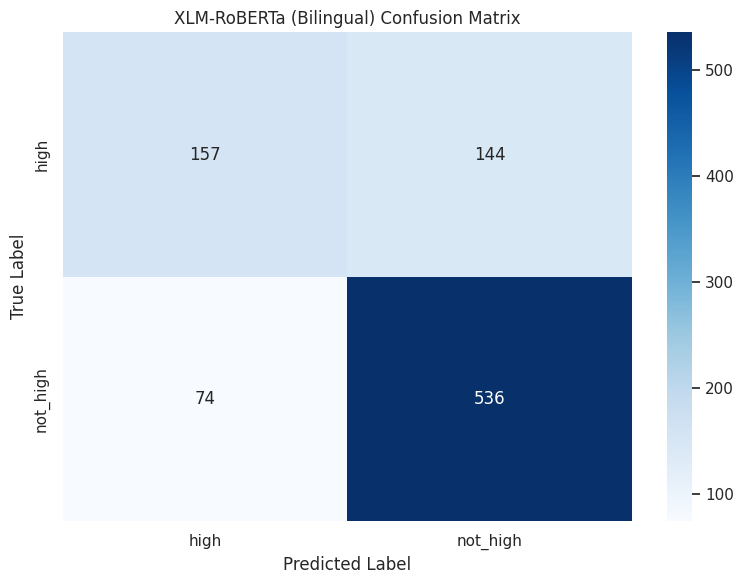

In [31]:
# 10. XLM-RoBERTa (Bilingual) classifier with explicit softmax on top
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Change to the multilingual model
xlm_model_name = "xlm-roberta-base"
xlm_tokenizer = AutoTokenizer.from_pretrained(xlm_model_name)

xlm_model = AutoModelForSequenceClassification.from_pretrained(
    xlm_model_name,
    num_labels=num_labels
)

# Train the bilingual model
xlm_model, xlm_best_f1 = train_transformer_classifier(
    xlm_model,
    xlm_tokenizer,
    train_df,
    val_df,
    num_epochs=3,
    batch_size=16,
    max_length=128,
    lr=2e-5
)

def xlm_predict_with_softmax(texts):
    xlm_model.eval()
    xlm_model.to(device)
    enc = xlm_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        outputs = xlm_model(**enc)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
    preds = np.argmax(probs, axis=1)
    labels = label_encoder.inverse_transform(preds)
    return labels, probs

val_labels = val_df["label_id"].values
_, xlm_probs = xlm_predict_with_softmax(val_df["post_text_en"].tolist())
xlm_preds = np.argmax(xlm_probs, axis=1)

# Print Metrics
print("XLM-RoBERTa accuracy:", accuracy_score(val_labels, xlm_preds))
print("XLM-RoBERTa macro F1:", f1_score(val_labels, xlm_preds, average="macro"))
print(classification_report(val_labels, xlm_preds, target_names=label_encoder.classes_))

# Calculate the confusion matrix
cm = confusion_matrix(val_labels, xlm_preds)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title('XLM-RoBERTa (Bilingual) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 1/3 - val: 100%|██████████| 57/

Epoch 1: train_loss=0.5559, val_acc=0.7783, val_macro_f1=0.7450


Epoch 2/3 - val: 100%|██████████| 57/57 [00:04<00:00, 13.85it/s]


Epoch 2: train_loss=0.4224, val_acc=0.7750, val_macro_f1=0.7282


Epoch 3/3 - val: 100%|██████████| 57/57 [00:04<00:00, 13.97it/s]


Epoch 3: train_loss=0.3421, val_acc=0.7717, val_macro_f1=0.7280
BERT accuracy: 0.7716794731064764
BERT macro F1: 0.7280191073294522
              precision    recall  f1-score   support

        high       0.69      0.56      0.62       301
    not_high       0.80      0.88      0.84       610

    accuracy                           0.77       911
   macro avg       0.75      0.72      0.73       911
weighted avg       0.76      0.77      0.76       911



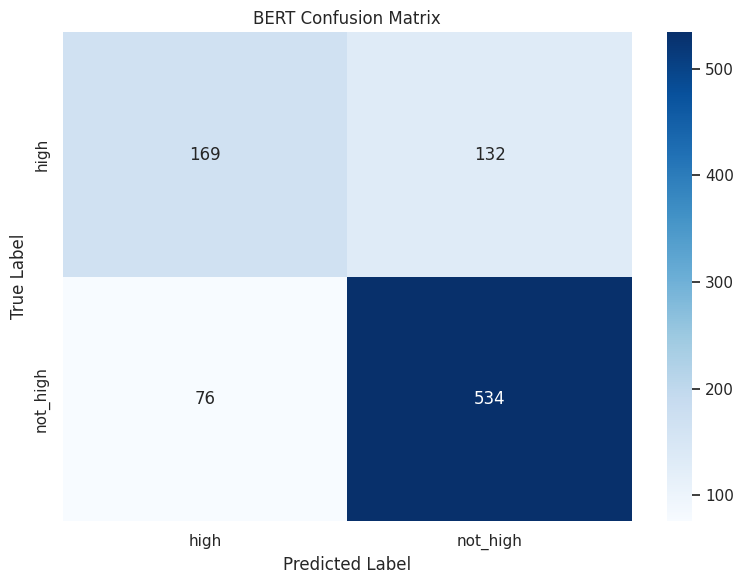

In [32]:
# 9. BERT-base classifier with explicit softmax on top
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


from transformers import AutoModelForSequenceClassification, AutoTokenizer

bert_model_name = "bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    bert_model_name,
    num_labels=num_labels
)

bert_model, bert_best_f1 = train_transformer_classifier(
    bert_model,
    bert_tokenizer,
    train_df,
    val_df,
    num_epochs=3,
    batch_size=16,
    max_length=128,
    lr=2e-5
)

def bert_predict_with_softmax(texts):
    bert_model.eval()
    bert_model.to(device)
    enc = bert_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        outputs = bert_model(**enc)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
    preds = np.argmax(probs, axis=1)
    labels = label_encoder.inverse_transform(preds)
    return labels, probs

val_labels = val_df["label_id"].values
_, bert_probs = bert_predict_with_softmax(val_df["post_text_en"].tolist())
bert_preds = np.argmax(bert_probs, axis=1)

print("BERT accuracy:", accuracy_score(val_labels, bert_preds))
print("BERT macro F1:", f1_score(val_labels, bert_preds, average="macro"))
print(classification_report(val_labels, bert_preds, target_names=label_encoder.classes_))
# Calculate the confusion matrix
cm = confusion_matrix(val_labels, bert_preds)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title('BERT Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch 1: train_loss=0.5714, val_acc=0.7552, val_macro_f1=0.7140


Epoch 2/3 - val: 100%|██████████| 57/57 [00:03<00:00, 15.18it/s]


Epoch 2: train_loss=0.4488, val_acc=0.7958, val_macro_f1=0.7417


Epoch 3/3 - val: 100%|██████████| 57/57 [00:03<00:00, 15.14it/s]


Epoch 3: train_loss=0.3740, val_acc=0.8002, val_macro_f1=0.7600
RoBERTa accuracy: 0.8002195389681669
RoBERTa macro F1: 0.7599827444440584
              precision    recall  f1-score   support

        high       0.75      0.59      0.66       301
    not_high       0.82      0.90      0.86       610

    accuracy                           0.80       911
   macro avg       0.78      0.75      0.76       911
weighted avg       0.80      0.80      0.79       911



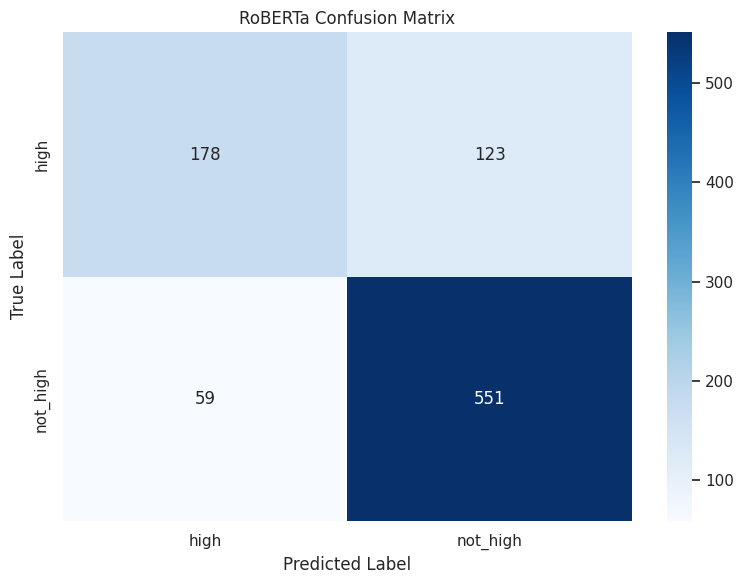

In [33]:
# 10. RoBERTa-base classifier with explicit softmax on top

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

roberta_model_name = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_model_name)

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    roberta_model_name,
    num_labels=num_labels
)

roberta_model, roberta_best_f1 = train_transformer_classifier(
    roberta_model,
    roberta_tokenizer,
    train_df,
    val_df,
    num_epochs=3,
    batch_size=16,
    max_length=128,
    lr=2e-5
)

def roberta_predict_with_softmax(texts):
    roberta_model.eval()
    roberta_model.to(device)
    enc = roberta_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        outputs = roberta_model(**enc)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
    preds = np.argmax(probs, axis=1)
    labels = label_encoder.inverse_transform(preds)
    return labels, probs

_, roberta_probs = roberta_predict_with_softmax(val_df["post_text_en"].tolist())
roberta_preds = np.argmax(roberta_probs, axis=1)

print("RoBERTa accuracy:", accuracy_score(val_labels, roberta_preds))
print("RoBERTa macro F1:", f1_score(val_labels, roberta_preds, average="macro"))
print(classification_report(val_labels, roberta_preds, target_names=label_encoder.classes_))



# Calculate the confusion matrix
cm = confusion_matrix(val_labels, roberta_preds)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title('RoBERTa Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [34]:
# 11. Simple ensemble: average BERT and RoBERTa probabilities

ensemble_probs = (bert_probs + roberta_probs) / 2.0
ensemble_preds = np.argmax(ensemble_probs, axis=1)

print("Ensemble accuracy:", accuracy_score(val_labels, ensemble_preds))
print("Ensemble macro F1:", f1_score(val_labels, ensemble_preds, average="macro"))
print(classification_report(val_labels, ensemble_preds, target_names=label_encoder.classes_))

Ensemble accuracy: 0.7859495060373216
Ensemble macro F1: 0.7419994335882186
              precision    recall  f1-score   support

        high       0.73      0.56      0.64       301
    not_high       0.81      0.90      0.85       610

    accuracy                           0.79       911
   macro avg       0.77      0.73      0.74       911
weighted avg       0.78      0.79      0.78       911



In [35]:

# 12. Collect metrics

results = []

tfidf_lr_macro_f1 = f1_score(val_df["label_id"], val_pred_lr, average="macro")
tfidf_lr_acc = accuracy_score(val_df["label_id"], val_pred_lr)

bert_macro_f1 = f1_score(val_labels, bert_preds, average="macro")
bert_acc = accuracy_score(val_labels, bert_preds)

roberta_macro_f1 = f1_score(val_labels, roberta_preds, average="macro")
roberta_acc = accuracy_score(val_labels, roberta_preds)

ensemble_macro_f1 = f1_score(val_labels, ensemble_preds, average="macro")
ensemble_acc = accuracy_score(val_labels, ensemble_preds)

results.append(["TF-IDF + LR", tfidf_lr_acc, tfidf_lr_macro_f1])
results.append(["BERT-base", bert_acc, bert_macro_f1])
results.append(["RoBERTa-base", roberta_acc, roberta_macro_f1])
results.append(["BERT + RoBERTa ensemble", ensemble_acc, ensemble_macro_f1])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Val Accuracy", "Val Macro F1"]
)
print(results_df)

                     Model  Val Accuracy  Val Macro F1
0              TF-IDF + LR      0.765093      0.738808
1                BERT-base      0.771679      0.728019
2             RoBERTa-base      0.800220      0.759983
3  BERT + RoBERTa ensemble      0.785950      0.741999
